# Fraud Detection in Financial Transactions

**Portfolio Project — Fraud Analytics, Machine Learning, SQL & Power BI**

This notebook develops a fraud detection workflow for financial transactions. The objective is not only to train a model, but to convert model outputs into operational fraud monitoring insights that can be reused in SQL and Power BI dashboards.

## Executive Summary

This project simulates an end-to-end fraud analytics workflow for a financial institution or fintech environment.

**Business objective:** identify suspicious financial transactions, reduce undetected fraud exposure, and support fraud analysts with a prioritised alert workflow.

**Final strategy:** the retained model prioritises high recall to capture almost all confirmed fraud cases, while accepting a controlled level of false positives. This is realistic for fraud monitoring, where missing fraud can create direct financial loss and operational risk.

**End-to-end workflow:** Python is used for data understanding, feature engineering, model training, leakage control and prediction export. SQL transforms prediction outputs into fraud monitoring indicators. Power BI presents executive KPIs and operational investigation views.

## Project Architecture

```mermaid
flowchart TD
    A[Raw financial transaction data] --> B[fraud detection pipeline]
    B --> C[cleaning/exploratory analysis]
    C --> D[Feature engineering/leakage review]
    D --> E[Baseline/clean ML models]
    E --> F[Fraud probability scoring]
    F --> G[Prediction export CSV]
    G --> H[SQL fraud analytics]
    H --> I[monitoring dashboard]
    I --> J[Reporting/ investigation]
```

# 1. Data Understanding



This dataset contains financial transactions performed by customers.
The objective is to detect fraudulent transactions using behavioral
patterns and transaction characteristics.

Each observation represents a single transaction.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# GitHub/recruiter-friendly data loading.
# Works whether the notebook is executed from the repository root or from a notebooks/ folder.
import pandas as pd

df = pd.read_csv(r"C:\Users\LENOVO\Desktop\Projet 2 Fraud Detection\First_Dataset_CT.csv")

print(df.shape)
df.head(10)

(6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.0,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.0,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.0,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.0,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.0,0.00,0,0
5,1,PAYMENT,7817.71,C90045638,53860.00,46042.29,M573487274,0.0,0.00,0,0
6,1,PAYMENT,7107.77,C154988899,183195.00,176087.23,M408069119,0.0,0.00,0,0
7,1,PAYMENT,7861.64,C1912850431,176087.23,168225.59,M633326333,0.0,0.00,0,0
8,1,PAYMENT,4024.36,C1265012928,2671.00,0.00,M1176932104,0.0,0.00,0,0
9,1,DEBIT,5337.77,C712410124,41720.00,36382.23,C195600860,41898.0,40348.79,0,0


## Dataset description

The dataset contains the following variables:

- **step** : time step representing the chronological order of transactions  
- **type** : type of transaction (CASH_IN, CASH_OUT, PAYMENT, TRANSFER, DEBIT)  
- **amount** : transaction amount  
- **nameOrig** : origin account  
- **oldbalanceOrg** : balance before transaction (origin account)  
- **newbalanceOrig** : balance after transaction (origin account)  
- **nameDest** : destination account  
- **oldbalanceDest** : balance before transaction (destination account)  
- **newbalanceDest** : balance after transaction (destination account)  
- **isFraud** : fraud indicator (1 = fraud, 0 = legitimate)  
- **isFlaggedFraud** : system flagged fraud indicator

In [3]:
df.shape

(6362620, 11)

In [4]:
df.dtypes

step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [6]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


## 2. Data Cleaning

In [7]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

No missing values are present in the dataset.

Therefore, no imputation or missing data treatment is required.

In [8]:
df.duplicated().sum()

np.int64(0)

No duplicate transactions were detected.

## 3. Exploratory Data Analysis

In [9]:
df["isFraud"].value_counts(normalize = True)

isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64

The dataset is extremely imbalanced.

Fraudulent transactions represent only about **0.13%** of the dataset.

This class imbalance is typical in fraud detection problems and must be considered during model training since accuracy alone can be misleading.

In [10]:
df["type"].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

Most transactions are CASH_OUT and PAYMENT operations.

However, fraudulent transactions are primarily associated
with TRANSFER and CASH_OUT operations.

In [11]:
df.groupby("type")["isFraud"].mean()

type
CASH_IN     0.000000
CASH_OUT    0.001840
DEBIT       0.000000
PAYMENT     0.000000
TRANSFER    0.007688
Name: isFraud, dtype: float64

Fraudulent transactions are mainly associated with **TRANSFER** and **CASH_OUT** operations.

Other transaction types such as PAYMENT, CASH_IN, and DEBIT show almost no fraudulent activity in this dataset.

In [12]:
df.groupby("isFraud")["amount"].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,1.781970e+05,5.962370e+05,0.01,13368.395,74684.72,208364.76,92445516.64
1,8213.0,1.467967e+06,2.404253e+06,0.00,127091.330,441423.44,1517771.48,10000000.00


Fraudulent transactions tend to involve significantly larger amounts compared to legitimate transactions.

This suggests that transaction amount may be an important feature for detecting fraud.

In [13]:
df["errorOrig"] = df["oldbalanceOrg"] - df["amount"] - df["newbalanceOrig"]
df["errorDest"] = df["oldbalanceDest"] + df["amount"] - df["newbalanceDest"]

 Balance inconsistency features used to detect abnormal transaction behavior.
In legitimate transactions, account balances should update consistently after money transfers.
Large discrepancies between expected and actual balances may indicate fraudulent activity, system anomalies, or suspicious transaction patterns.



In [14]:
df.groupby("isFraud")[["errorOrig","errorDest"]].mean()

,errorOrig,errorDest
isFraud,,
0,-201338.558109,54692.231734
1,-10692.325265,732509.301069


Fraudulent transactions show stronger balance inconsistencies than legitimate transactions.

These discrepancies suggest that abnormal balance updates may be useful indicators for fraud detection.

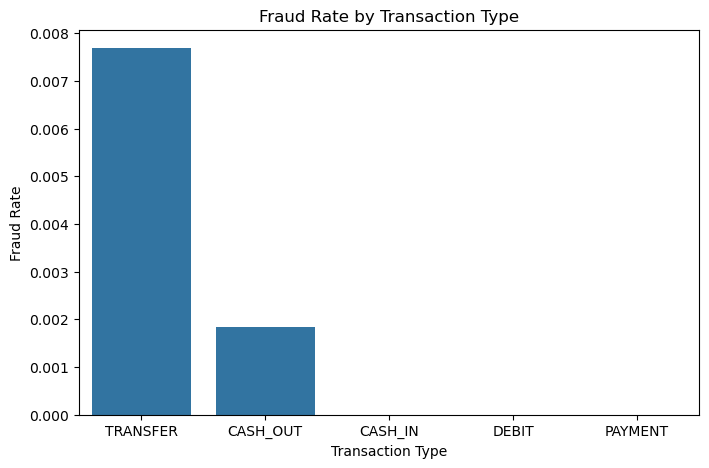

In [15]:
fraud_rate = df.groupby("type")["isFraud"].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=fraud_rate.index, y=fraud_rate.values)

plt.title("Fraud Rate by Transaction Type")
plt.ylabel("Fraud Rate")
plt.xlabel("Transaction Type")

plt.show()

## Key Insights from Exploratory Analysis

Several patterns emerge from the exploratory analysis:

1. The dataset is highly imbalanced, with fraudulent transactions representing less than 0.2% of the data.
2. Fraud occurs almost exclusively in **TRANSFER** and **CASH_OUT** transaction types.
3. Fraudulent transactions involve significantly larger amounts.
4. Balance inconsistencies appear in fraudulent transactions, suggesting manipulation of account balances.

These insights will guide the feature engineering and modeling phase.

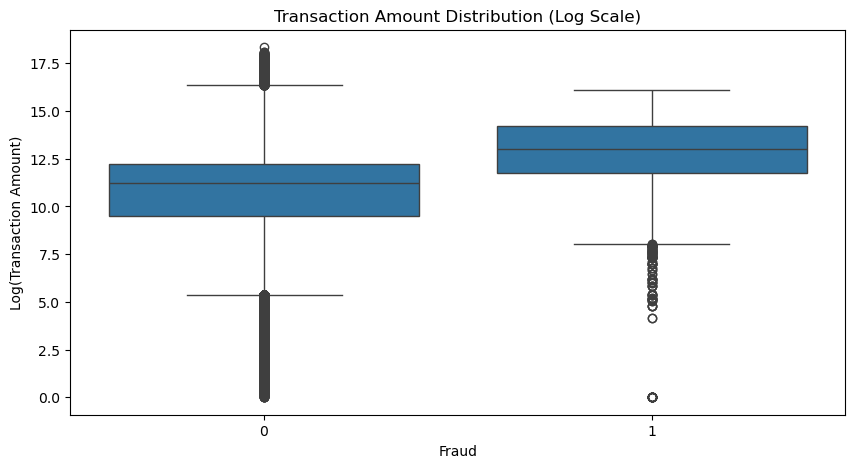

In [16]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x="isFraud",
    y=np.log1p(df["amount"]),
    data=df
)

plt.title("Transaction Amount Distribution (Log Scale)")
plt.xlabel("Fraud")
plt.ylabel("Log(Transaction Amount)")

plt.show()

 Transaction amounts are highly dispersed, which is typical in real-world financial datasets.
 Fraudulent transactions generally show higher transaction values than legitimate operations.
 Log transformation improves interpretability by reducing skewness caused by extreme transaction amounts.

## 4. Feature Engineering

In this section, we create additional variables that may help improve fraud detection by capturing abnormal transaction patterns and balance inconsistencies.

### Balance difference for the origin account

This variable measures the difference between the expected balance variation and the observed balance variation for the origin account.

Under normal conditions, the amount transferred should be consistent with the decrease in the sender’s balance.

A non-zero difference may indicate an abnormal balance update or an inconsistency in the transaction.

In [17]:
df["balanceDiffOrig"] = df["oldbalanceOrg"] - df["newbalanceOrig"] - df["amount"]


### Balance difference for the destination account

This feature captures the gap between the expected increase in the destination balance and the actual balance recorded after the transaction.

In a legitimate transaction, the destination balance should increase by approximately the transferred amount.

Large discrepancies may reveal suspicious behavior or irregularities in the transaction flow.

In [18]:
df["balanceDiffDest"] = df["newbalanceDest"] - df["oldbalanceDest"] - df["amount"]

### Origin account emptied after transaction

This binary variable indicates whether the sender’s balance becomes zero after the transaction.

Completely emptying an account can be a suspicious pattern, especially in fraudulent transfers where funds are quickly moved out of the original account.

In [19]:
df["origZeroAfterTx"] = (df["newbalanceOrig"] == 0).astype(int)

### Destination account with no previous balance

This variable identifies destination accounts that had no recorded balance before receiving the transaction.

Such accounts may represent newly used or inactive accounts, which can be relevant in fraud scenarios when funds are transferred to less established destinations.

In [20]:
df["destNoOldBalance"] = (df["oldbalanceDest"] == 0).astype(int)

### High-risk transaction type

Previous exploratory analysis showed that fraudulent transactions are concentrated in TRANSFER and CASH_OUT operations.

This binary feature flags transactions belonging to these higher-risk categories and summarizes this business insight into a single modeling variable.

In [21]:
df["isHighRiskType"] = df["type"].isin(["TRANSFER", "CASH_OUT"]).astype(int)

In [22]:
df[[
"balanceDiffOrig",
"balanceDiffDest",
"origZeroAfterTx",
"destNoOldBalance",
"isHighRiskType"
]].describe()

,balanceDiffOrig,balanceDiffDest,origZeroAfterTx,destNoOldBalance,isHighRiskType
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,-2.010925e+05,-5.556717e+04,5.673081e-01,4.250431e-01,4.354195e-01
std,6.066505e+05,4.415288e+05,4.954489e-01,4.943496e-01,4.958119e-01
min,-9.244552e+07,-1.319123e+07,0.000000e+00,0.000000e+00,0.000000e+00
25%,-2.496411e+05,-2.935305e+04,0.000000e+00,0.000000e+00,0.000000e+00
50%,-6.867726e+04,-3.500490e+03,1.000000e+00,0.000000e+00,0.000000e+00
75%,-2.954230e+03,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
max,1.000000e-02,7.588573e+07,1.000000e+00,1.000000e+00,1.000000e+00


These engineered features transform raw transactional information into more informative indicators of abnormal behavior.

They are expected to improve the model’s ability to distinguish between legitimate and fraudulent transactions.

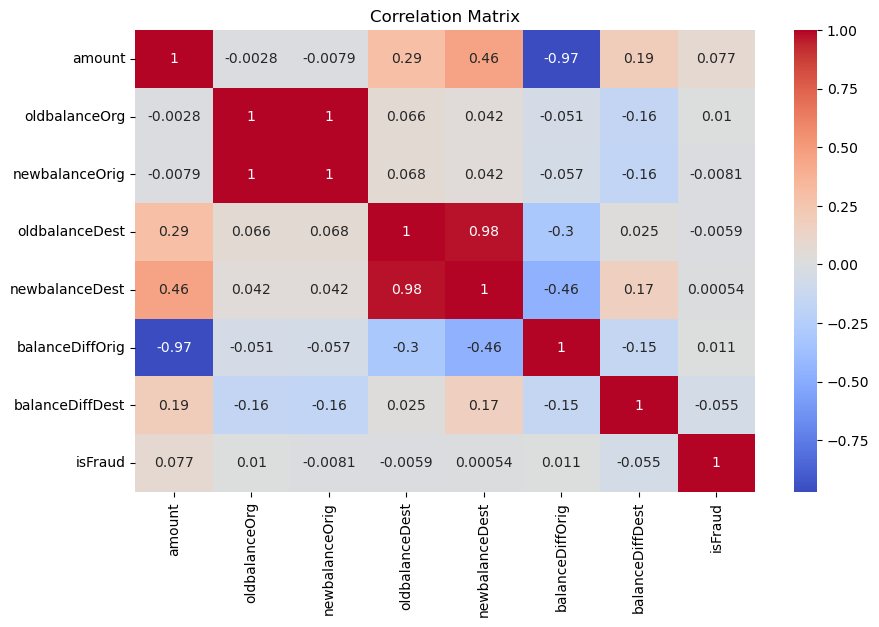

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(df[[
"amount",
"oldbalanceOrg",
"newbalanceOrig",
"oldbalanceDest",
"newbalanceDest",
"balanceDiffOrig",
"balanceDiffDest",
"isFraud"
]].corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

The correlation matrix helps identify relationships between variables and highlights which features may contribute to fraud prediction.

### Correlation Analysis

The correlation matrix provides insights into the relationships between the main numerical variables and the fraud indicator.

Several observations can be highlighted:

• **Strong correlations between balance variables**  
`oldbalanceOrg` and `newbalanceOrig` show an almost perfect positive correlation, which is expected since account balances are updated after each transaction.

Similarly, `oldbalanceDest` and `newbalanceDest` are strongly correlated, reflecting the natural balance update process on the recipient account.

• **Strong negative correlation between amount and balanceDiffOrig**  
The variable `balanceDiffOrig` is strongly negatively correlated with the transaction amount. This is expected because this engineered feature measures the difference between the expected balance change and the actual balance change.

• **Limited linear correlation with fraud**  
Most variables show relatively low linear correlation with the `isFraud` target. This is common in fraud detection problems, where fraudulent patterns are often complex and not captured through simple linear relationships.

• **Importance of engineered features**  
Even though correlations with fraud are relatively weak, the engineered variables such as `balanceDiffOrig` and `balanceDiffDest` may still capture important behavioral anomalies that machine learning models can exploit.

Overall, the correlation analysis suggests that while some variables are strongly related to each other, detecting fraud will likely require a combination of multiple features and more advanced modeling techniques.

Fraud detection rarely relies on a single variable but rather on complex patterns across multiple transaction attributes.

## 5. Fraud Filtering Strategy

Exploratory analysis revealed that fraudulent transactions occur only in TRANSFER and CASH_OUT operations.

To focus the modeling process on relevant transactions and reduce noise in the dataset, the analysis will focus on these transaction types.

This approach reflects real-world fraud detection pipelines, where rule-based filtering is often applied before machine learning models.

In [24]:
df_model =df[df["type"].isin(["TRANSFER", "CASH_OUT"])].copy()

In [25]:
df_model["type"].value_counts()

type
CASH_OUT    2237500
TRANSFER     532909
Name: count, dtype: int64

In [26]:
df_model["isFraud"].value_counts(normalize=True)

isFraud
0    0.997035
1    0.002965
Name: proportion, dtype: float64

After filtering the dataset to only include TRANSFER and CASH_OUT transactions, the proportion of fraudulent transactions increases.

This improves the signal available for machine learning models while keeping the analysis focused on the most relevant transaction types.

### Dataset after transaction type filtering

After restricting the dataset to TRANSFER and CASH_OUT transactions, the dataset contains:

- 2,237,500 CASH_OUT transactions
- 532,909 TRANSFER transactions

This confirms that these two transaction types represent the main operations where fraud occurs in the dataset.

The fraud ratio increases to approximately **0.30%**, compared to about **0.13% in the original dataset**.

Although fraud remains a rare event, focusing on these transaction types improves the signal available for fraud detection models and reduces noise from transaction types that never contain fraud.

## 6. Data Preparation for Modeling

In this stage, the dataset is prepared for machine learning modeling.  
Relevant features are selected and the data is split into training and testing sets.

In [27]:
features = [
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "balanceDiffOrig",
    "balanceDiffDest",
    "origZeroAfterTx",
    "destNoOldBalance",
    "isHighRiskType"
]

X = df_model[features]
y = df_model["isFraud"]

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [29]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (2216327, 10)
Test shape: (554082, 10)


Because fraud is extremely rare, stratified sampling ensures that both the training and testing sets maintain the same proportion of fraudulent transactions.

### Train / Test Split

The dataset was divided into training and testing sets using an 80/20 split.

• Training set: 2,216,327 transactions  
• Test set: 554,082 transactions  

Stratified sampling was applied to preserve the proportion of fraudulent transactions in both datasets. This is essential in fraud detection problems where the target variable is highly imbalanced.

## 7. Baseline Fraud Detection Model

To establish a baseline model for fraud detection, a Logistic Regression classifier is trained.

Given the strong class imbalance in the dataset, class weights are used to penalize misclassification of fraudulent transactions.

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

### Baseline Model Performance

The Logistic Regression model provides an initial benchmark for fraud detection.

Due to the extreme class imbalance in the dataset, class weighting was applied to ensure the model gives sufficient importance to fraudulent transactions.

The evaluation focuses on precision, recall and F1-score for the fraud class rather than overall accuracy.

In [31]:
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [32]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [33]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.93      0.97    552439
           1       0.04      0.91      0.08      1643

    accuracy                           0.93    554082
   macro avg       0.52      0.92      0.52    554082
weighted avg       1.00      0.93      0.96    554082



In [34]:
print("ROC AUC:", roc_auc_score(y_test, y_prob))

ROC AUC: 0.982462346302546


### Model Performance Analysis

The Logistic Regression model achieves a ROC AUC score of 0.982, indicating strong ability to distinguish between fraudulent and legitimate transactions.

The model achieves a recall of 0.91 for fraudulent transactions, meaning that 91% of fraud cases are successfully detected.

However, the precision for fraud is relatively low (0.04), indicating that many transactions flagged as fraud are actually legitimate. This is a common issue in fraud detection due to the extreme class imbalance in the dataset.

In fraud detection systems, high recall is often prioritized to minimize undetected fraudulent transactions, even at the cost of increased false positives.

### Confusion Matrix

The confusion matrix provides a detailed breakdown of correct and incorrect predictions made by the model.

It highlights the number of true positives, false positives, true negatives, and false negatives, which is particularly important in fraud detection problems.

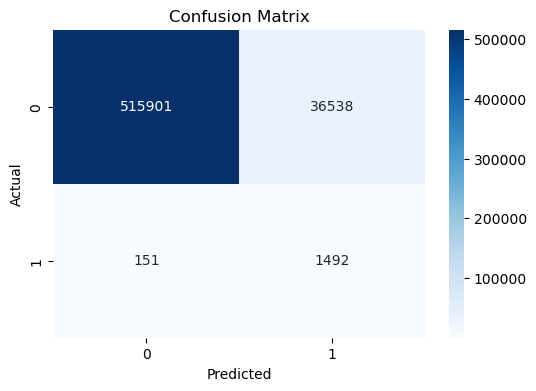

In [35]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

### Confusion Matrix Analysis

The confusion matrix highlights how the model performs on fraudulent and legitimate transactions.

• True Negatives: 515,901 legitimate transactions were correctly classified.

• False Positives: 36,538 legitimate transactions were incorrectly flagged as fraud.

• True Positives: 1,492 fraudulent transactions were correctly detected.

• False Negatives: Only 151 fraudulent transactions were missed.

The model successfully detects the majority of fraud cases, but it generates a relatively high number of false positives. This behavior is common in fraud detection systems where detecting fraud is prioritized over minimizing alerts.

### ROC Curve

The ROC curve illustrates the trade-off between the true positive rate and the false positive rate across different classification thresholds.

It provides a visual representation of the model’s ability to distinguish between fraudulent and legitimate transactions.

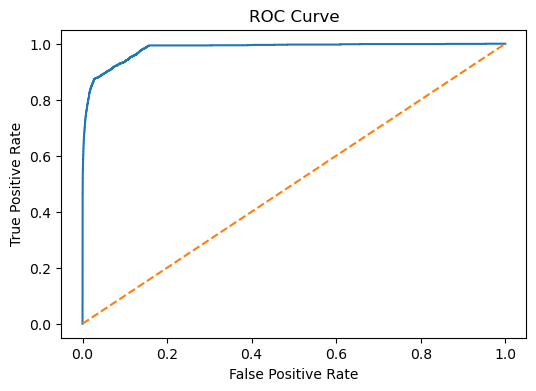

In [36]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

### ROC Curve Interpretation

The ROC curve shows that the model achieves a strong ability to distinguish between fraudulent and legitimate transactions.

The ROC AUC score of 0.982 indicates excellent discrimination performance. This means the model is highly effective at assigning higher fraud probabilities to fraudulent transactions compared to normal ones.

### Precision-Recall Curve

In highly imbalanced datasets such as fraud detection, the Precision-Recall curve provides a more informative evaluation of model performance.

It shows the trade-off between detecting fraud (recall) and minimizing false alerts (precision).

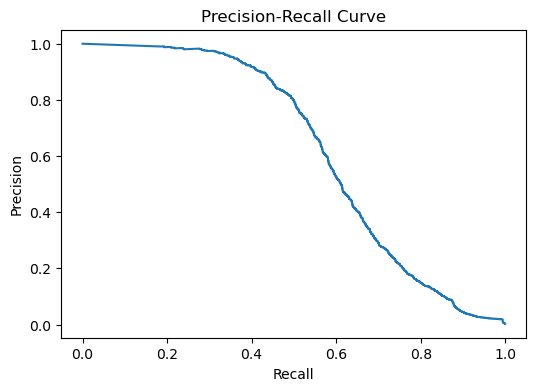

In [37]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

### Precision-Recall Curve Interpretation

The Precision-Recall curve illustrates the trade-off between detecting fraud (recall) and minimizing false alerts (precision).

In highly imbalanced datasets such as fraud detection, the Precision-Recall curve provides a more informative evaluation of model performance than accuracy.

The curve shows that achieving very high recall leads to a reduction in precision, highlighting the challenge of balancing fraud detection with false positive alerts.

## 8. Threshold Optimization

In fraud detection systems, the default classification threshold of 0.5 is rarely optimal due to extreme class imbalance.

Adjusting the decision threshold allows financial institutions to control the trade-off between fraud detection (recall) and false alerts (precision).

This section evaluates multiple thresholds to determine the most appropriate operating point for the fraud detection model.

In [38]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.5, 0.4, 0.3, 0.2, 0.1]

results = []

for t in thresholds:
    
    y_pred_thresh = (y_prob >= t).astype(int)
    
    precision = precision_score(y_test, y_pred_thresh)
    recall = recall_score(y_test, y_pred_thresh)
    f1 = f1_score(y_test, y_pred_thresh)
    
    results.append((t, precision, recall, f1))

for r in results:
    print(f"Threshold: {r[0]} | Precision: {r[1]:.3f} | Recall: {r[2]:.3f} | F1-score: {r[3]:.3f}")

Threshold: 0.5 | Precision: 0.039 | Recall: 0.908 | F1-score: 0.075
Threshold: 0.4 | Precision: 0.031 | Recall: 0.929 | F1-score: 0.059
Threshold: 0.3 | Precision: 0.024 | Recall: 0.953 | F1-score: 0.047
Threshold: 0.2 | Precision: 0.019 | Recall: 0.990 | F1-score: 0.037
Threshold: 0.1 | Precision: 0.009 | Recall: 0.995 | F1-score: 0.019


In [39]:
import pandas as pd

threshold_results = pd.DataFrame(results, columns=[
    "Threshold",
    "Precision",
    "Recall",
    "F1_score"
])

threshold_results

,Threshold,Precision,Recall,F1_score
0,0.5,0.039232,0.908095,0.075215
1,0.4,0.030529,0.928789,0.059114
2,0.3,0.023990,0.953135,0.046802
3,0.2,0.018847,0.989653,0.036989
4,0.1,0.009481,0.994522,0.018782


Lower classification thresholds increase fraud detection sensitivity (recall)
but also generate more false positive alerts, reducing precision.
Threshold optimization is critical in fraud detection systems to balance
operational efficiency and fraud prevention performance.

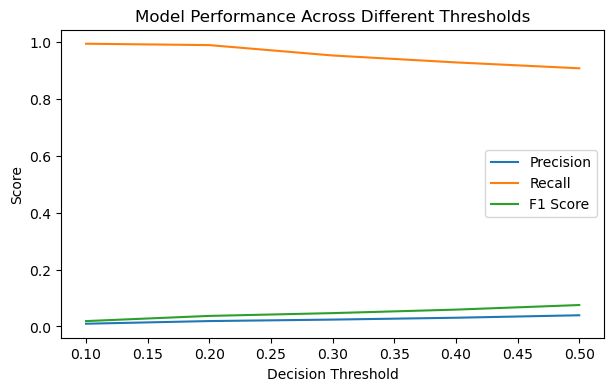

In [40]:
plt.figure(figsize=(7,4))

plt.plot(threshold_results["Threshold"], threshold_results["Precision"], label="Precision")
plt.plot(threshold_results["Threshold"], threshold_results["Recall"], label="Recall")
plt.plot(threshold_results["Threshold"], threshold_results["F1_score"], label="F1 Score")

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Model Performance Across Different Thresholds")

plt.legend()

plt.show()

 Lower thresholds increase fraud detection sensitivity (recall)
 but significantly reduce precision due to a higher number of false positive alerts.
Threshold selection should therefore align with business objectives
 and operational fraud management constraints.

### Threshold Selection

The threshold analysis shows how model performance changes when adjusting the fraud classification threshold.

Lower thresholds increase recall, allowing the model to detect a larger proportion of fraudulent transactions. However, this leads to a substantial drop in precision, meaning a larger number of legitimate transactions are incorrectly flagged as fraud.

The threshold of 0.5 provides the highest F1-score among the evaluated thresholds and represents a reasonable balance between precision and recall for the baseline model.
Therefore, the baseline fraud detection model will retain a threshold of 0.5 for the subsequent analysis.

## 9. Random Forest Model and Leakage Detection

While logistic regression provides a strong baseline model, tree-based algorithms are often better suited for fraud detection problems.

Random Forest models are capable of capturing non-linear relationships and complex interactions between variables, which can improve detection performance in highly imbalanced datasets.

In this section, we train a Random Forest classifier and compare its performance to the baseline logistic regression model.

In [41]:
# Use a fraud-aware representative sample to keep the baseline Random Forest fast and reproducible.
# The model is trained on all fraud cases from the training set plus a reproducible
# sample of legitimate transactions, then evaluated on the full test set.

fraud_train_idx = y_train[y_train == 1].index
legit_train_idx = y_train[y_train == 0].sample(
    n=min(100000, (y_train == 0).sum()),
    random_state=42
).index

sample_idx = fraud_train_idx.union(legit_train_idx)

X_train_rf_sample = X_train.loc[sample_idx]
y_train_rf_sample = y_train.loc[sample_idx]

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

rf_model = RandomForestClassifier(
    n_estimators=30,
    max_depth=8,
    min_samples_leaf=20,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=1
)

rf_model.fit(X_train_rf_sample, y_train_rf_sample)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Baseline Random Forest training sample:", X_train_rf_sample.shape)
print(classification_report(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_prob_rf))


Baseline Random Forest training sample: (106570, 10)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    552439
           1       1.00      1.00      1.00      1643

    accuracy                           1.00    554082
   macro avg       1.00      1.00      1.00    554082
weighted avg       1.00      1.00      1.00    554082

ROC AUC: 0.9993879308698583


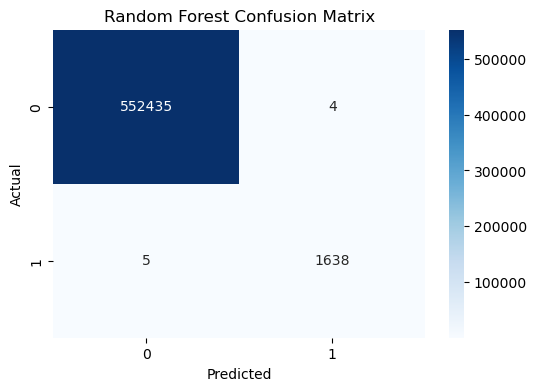

In [42]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

### Random Forest Model Evaluation

The Random Forest model is able to capture more complex patterns in the data compared to logistic regression.

Tree-based models are particularly useful in fraud detection because they can identify nonlinear relationships between transaction characteristics and fraudulent behavior.

The performance metrics and confusion matrix allow us to evaluate whether the Random Forest model improves fraud detection compared to the baseline logistic regression model.

In [43]:
importances = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": importances
}).sort_values(by="importance", ascending=False)

feature_importance

,feature,importance
5,balanceDiffOrig,0.458811
1,oldbalanceOrg,0.228035
4,newbalanceDest,0.087513
6,balanceDiffDest,0.058933
2,newbalanceOrig,0.048128
7,origZeroAfterTx,0.043000
0,amount,0.037007
3,oldbalanceDest,0.026911
8,destNoOldBalance,0.011662
9,isHighRiskType,0.000000


### Data Leakage Detection

During the evaluation of the Random Forest model, the model initially achieved near-perfect performance.

Further investigation of feature importance revealed that several balance-related variables were directly encoding the outcome of fraudulent transactions.

These variables created a form of data leakage, allowing the model to trivially identify fraud without learning meaningful behavioral patterns.

To ensure a more realistic fraud detection model, these variables were removed and the model was retrained using only features that would realistically be available in a real-time fraud detection system.

## 9.1 Removing Data Leakage Features

 Use the filtered dataset only (TRANSFER and CASH_OUT), then keep only realistic features
 for a fraud monitoring model without the leakage variables identified above.

 IMPORTANT:
 The original transaction type is preserved in df_model_clean["type"].
 It is only encoded for the machine learning model, because scikit-learn requires numeric inputs.
 For exports and Power BI, the real transaction type will be kept as "typeTransaction"
 instead of only having a True/False dummy column.

 Use the original dataset and keep only realistic features
 after removing leakage-prone variables identified previously.

In [44]:
# Create high-risk transaction type flag
df["isHighRiskType"] = df["type"].isin(["TRANSFER", "CASH_OUT"]).astype(int)

# Use the original dataset and keep only realistic features
df_model_clean = df.copy()

features_clean = [
    "step",
    "type",
    "amount",
    "oldbalanceOrg",
    "oldbalanceDest",
    "isHighRiskType"
]

# Define clean feature matrix and target variable
X_clean = df_model_clean[features_clean].copy()
y_clean = df_model_clean["isFraud"].copy()

# Encode categorical transaction type for machine learning
X_clean = pd.get_dummies(X_clean, columns=["type"], drop_first=True)

print("Clean feature set used by the model:")
print(X_clean.columns.tolist())
print("Shape:", X_clean.shape)

Clean feature set used by the model:
['step', 'amount', 'oldbalanceOrg', 'oldbalanceDest', 'isHighRiskType', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']
Shape: (6362620, 9)


In [45]:

from sklearn.model_selection import train_test_split

X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean,
    y_clean,
    test_size=0.2,
    random_state=42,
    stratify=y_clean
)

print("Train shape:", X_train_clean.shape)
print("Test shape:", X_test_clean.shape)


Train shape: (5090096, 9)
Test shape: (1272524, 9)


 Train a cleaner Random Forest model after removing leakage-prone variables.
 Class weights are used to handle the strong imbalance between legitimate and fraudulent transactions.
 The model is evaluated using precision, recall, F1-score, ROC AUC and Average Precision,
 which are more relevant than accuracy for fraud detection.

In [46]:
# Use a fraud-aware representative sample to keep the notebook fast and reproducible.
# All fraud cases from the training set are retained, and a reproducible sample
# of legitimate transactions is added. This preserves fraud signal while avoiding
# a slow notebook execution for recruiters.

fraud_train_idx = y_train_clean[y_train_clean == 1].index
legit_train_idx = y_train_clean[y_train_clean == 0].sample(
    n=min(100000, (y_train_clean == 0).sum()),
    random_state=42
).index

sample_idx = fraud_train_idx.union(legit_train_idx)

X_train_sample = X_train_clean.loc[sample_idx]
y_train_sample = y_train_clean.loc[sample_idx]

print("Sample training shape:", X_train_sample.shape)
print("Fraud cases in training sample:", int(y_train_sample.sum()))
print("Fraud rate in training sample:", round(y_train_sample.mean() * 100, 4), "%")

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score, confusion_matrix

rf_model_clean = RandomForestClassifier(
    n_estimators=30,
    max_depth=8,
    min_samples_leaf=20,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=1
)

rf_model_clean.fit(X_train_sample, y_train_sample)

y_pred_rf_clean = rf_model_clean.predict(X_test_clean)
y_prob_rf_clean = rf_model_clean.predict_proba(X_test_clean)[:, 1]

print(classification_report(y_test_clean, y_pred_rf_clean))
print("ROC AUC:", roc_auc_score(y_test_clean, y_prob_rf_clean))
print("Average Precision:", average_precision_score(y_test_clean, y_prob_rf_clean))

Sample training shape: (106570, 9)
Fraud cases in training sample: 6570
Fraud rate in training sample: 6.165 %
              precision    recall  f1-score   support

           0       1.00      0.96      0.98   1270881
           1       0.03      0.99      0.05      1643

    accuracy                           0.96   1272524
   macro avg       0.51      0.97      0.52   1272524
weighted avg       1.00      0.96      0.98   1272524

ROC AUC: 0.9976471112313722
Average Precision: 0.7576277459340226


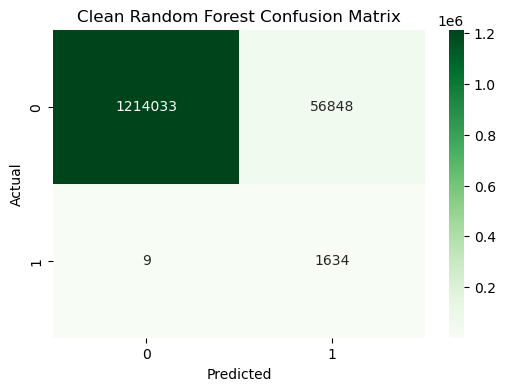

In [47]:
cm_rf_clean = confusion_matrix(y_test_clean, y_pred_rf_clean)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf_clean, annot=True, fmt="d", cmap="Greens")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Clean Random Forest Confusion Matrix")
plt.show()

In [48]:

feature_importance_clean = pd.DataFrame({
    "feature": X_train_clean.columns,
    "importance": rf_model_clean.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance_clean


,feature,importance
2,oldbalanceOrg,0.298863
4,isHighRiskType,0.214164
1,amount,0.173695
3,oldbalanceDest,0.087671
8,type_TRANSFER,0.071132
5,type_CASH_OUT,0.059193
0,step,0.049832
7,type_PAYMENT,0.045388
6,type_DEBIT,0.000064


## 10. Clean Random Forest Evaluation

This section completes the fraud modeling workflow after removing leakage variables.

The objective is to evaluate a more realistic fraud monitoring model based only on features that could be available in an operational environment.

In [49]:
clean_metrics = {
    "Model": "Random Forest (clean)",
    "ROC_AUC": roc_auc_score(y_test_clean, y_prob_rf_clean),
    "Average_Precision": average_precision_score(y_test_clean, y_prob_rf_clean),
    "Precision_class_1": classification_report(y_test_clean, y_pred_rf_clean, output_dict=True)["1"]["precision"],
    "Recall_class_1": classification_report(y_test_clean, y_pred_rf_clean, output_dict=True)["1"]["recall"],
    "F1_class_1": classification_report(y_test_clean, y_pred_rf_clean, output_dict=True)["1"]["f1-score"]
}

pd.DataFrame([clean_metrics]).round(4)

,Model,ROC_AUC,Average_Precision,Precision_class_1,Recall_class_1,F1_class_1
0,Random Forest (clean),0.9976,0.7576,0.0279,0.9945,0.0544


### Clean Model Interpretation

After removing the leakage variables, the model performance becomes more realistic.

This is the version that should be retained for a professional portfolio because it better reflects how a fraud monitoring model would behave in practice.

The most important evaluation criteria here are:
- **Recall on fraud cases**, because missed frauds are costly
- **Precision**, because too many false positives create operational friction
- **Average Precision**, which is especially informative for imbalanced fraud datasets

## Precision-Recall Evaluation

Fraud detection datasets are highly imbalanced.  
Precision-Recall analysis helps evaluate the model’s ability to detect fraud while controlling false alerts.

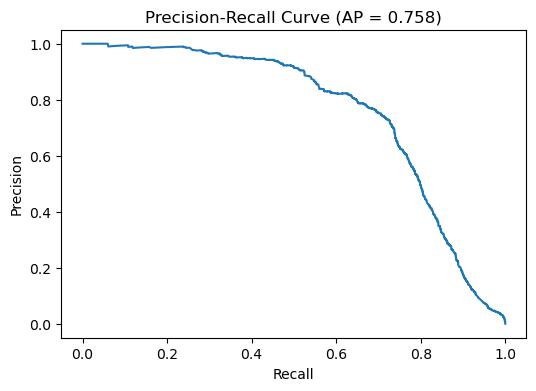

In [50]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(y_test_clean, y_prob_rf_clean)
ap_score = average_precision_score(y_test_clean, y_prob_rf_clean)

plt.figure(figsize=(6,4))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve (AP = {ap_score:.3f})")
plt.show()

In [51]:
thresholds_clean = [0.5, 0.4, 0.3, 0.2, 0.1]
clean_threshold_results = []

for t in thresholds_clean:
    y_pred_t = (y_prob_rf_clean >= t).astype(int)

    clean_threshold_results.append({
        "Threshold": t,
        "Precision": precision_score(y_test_clean, y_pred_t, zero_division=0),
        "Recall": recall_score(y_test_clean, y_pred_t, zero_division=0),
        "F1_score": f1_score(y_test_clean, y_pred_t, zero_division=0)
    })

clean_threshold_results = pd.DataFrame(clean_threshold_results)
clean_threshold_results

,Threshold,Precision,Recall,F1_score
0,0.5,0.027940,0.994522,0.054353
1,0.4,0.019613,0.998174,0.038470
2,0.3,0.016293,0.998174,0.032063
3,0.2,0.012708,0.998783,0.025097
4,0.1,0.007946,1.000000,0.015767


Lower classification thresholds improve fraud detection recall but significantly reduce precision by increasing the number of false positive alerts.

This trade-off is common in real-world fraud detection systems, where maximizing fraud detection sensitivity often comes at the cost of operational efficiency.

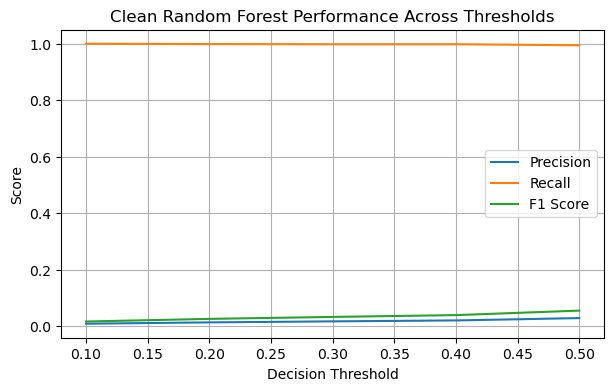

In [52]:
plt.figure(figsize=(7, 4))
plt.plot(clean_threshold_results["Threshold"], clean_threshold_results["Precision"], label="Precision")
plt.plot(clean_threshold_results["Threshold"], clean_threshold_results["Recall"], label="Recall")
plt.plot(clean_threshold_results["Threshold"], clean_threshold_results["F1_score"], label="F1 Score")

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Clean Random Forest Performance Across Thresholds")
plt.legend()
plt.grid(True)
plt.show()

The threshold analysis confirms the trade-off between fraud detection sensitivity and false positive control.

Higher thresholds improve precision and F1-score by reducing unnecessary fraud alerts, while recall remains relatively high across all evaluated thresholds.

A threshold of 0.5 provides the most balanced operational performance for the clean Random Forest model.

### Threshold Recommendation

For a fintech fraud use case, the final threshold should not be selected only on statistical performance.

It should also reflect business constraints:
- if the priority is to **catch as much fraud as possible**, a lower threshold may be preferred
- if the priority is to **reduce false alerts**, a higher threshold may be safer

In the portfolio presentation, you can explain that the threshold must be aligned with the fraud operations team's tolerance for false positives.

In [53]:
comparison_rows = []

comparison_rows.append({
    "Model": "Logistic Regression (baseline)",
    "ROC_AUC": roc_auc_score(y_test, y_prob),
    "Average_Precision": average_precision_score(y_test, y_prob),
    "Precision_class_1": classification_report(y_test, y_pred, output_dict=True)["1"]["precision"],
    "Recall_class_1": classification_report(y_test, y_pred, output_dict=True)["1"]["recall"],
    "F1_class_1": classification_report(y_test, y_pred, output_dict=True)["1"]["f1-score"]
})

comparison_rows.append({
    "Model": "Random Forest (with leakage)",
    "ROC_AUC": roc_auc_score(y_test, y_prob_rf),
    "Average_Precision": average_precision_score(y_test, y_prob_rf),
    "Precision_class_1": classification_report(y_test, y_pred_rf, output_dict=True)["1"]["precision"],
    "Recall_class_1": classification_report(y_test, y_pred_rf, output_dict=True)["1"]["recall"],
    "F1_class_1": classification_report(y_test, y_pred_rf, output_dict=True)["1"]["f1-score"]
})

comparison_rows.append(clean_metrics)

comparison_df = pd.DataFrame(comparison_rows).round(4)
comparison_df

,Model,ROC_AUC,Average_Precision,Precision_class_1,Recall_class_1,F1_class_1
0,Logistic Regression (baseline),0.9825,0.6192,0.0392,0.9081,0.0752
1,Random Forest (with leakage),0.9994,0.9979,0.9976,0.9970,0.9973
2,Random Forest (clean),0.9976,0.7576,0.0279,0.9945,0.0544


## 11. Final Model Choice

The final model retained for the portfolio should be the **clean Random Forest** or the **baseline logistic regression**, not the leaked Random Forest.

Why:
- the leaked Random Forest is not operationally credible
- the clean Random Forest is more realistic for fraud monitoring
- the logistic regression remains a strong benchmark because it is simpler and easier to interpret

In a fintech interview, this is a strong conclusion because it shows that model credibility matters more than artificially perfect scores.

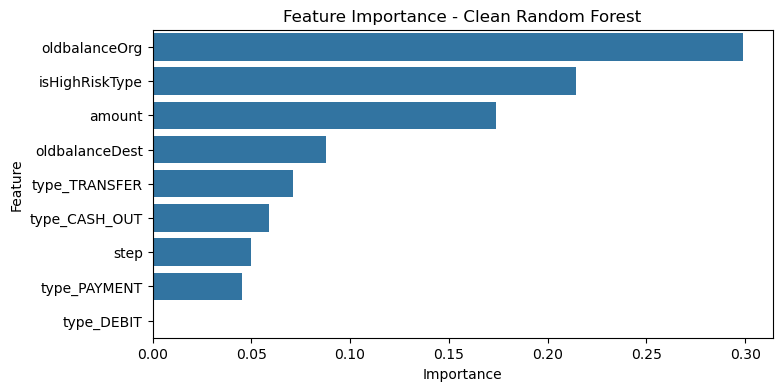

In [54]:
plt.figure(figsize=(8, 4))
sns.barplot(data=feature_importance_clean, x="importance", y="feature")
plt.title("Feature Importance - Clean Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

The clean Random Forest model relies primarily on transaction balance patterns and transaction amounts, which are realistic indicators of abnormal financial behavior in fraud monitoring systems.

In [55]:
# Create a readable prediction output for analysis / Power BI.
# The model was trained with an encoded transaction type, but the export keeps
# the original transaction type as typeTransaction so we can clearly see
# CASH_OUT or TRANSFER instead of a True/False dummy column.

predictions_clean = X_test_clean.copy()

# Restore the original transaction type from df_model_clean using the preserved index.
predictions_clean.insert(
    1,
    "typeTransaction",
    df_model_clean.loc[predictions_clean.index, "type"].values
)

# Remove encoded dummy columns from the exported prediction file to avoid confusion.
type_dummy_columns = [col for col in predictions_clean.columns if col.startswith("type_")]
predictions_clean = predictions_clean.drop(columns=type_dummy_columns)

predictions_clean["actual_isFraud"] = y_test_clean.values
predictions_clean["predicted_isFraud"] = y_pred_rf_clean
predictions_clean["predicted_probability"] = y_prob_rf_clean

predictions_clean.head()

,step,typeTransaction,amount,oldbalanceOrg,oldbalanceDest,isHighRiskType,actual_isFraud,predicted_isFraud,predicted_probability
4051353,300,TRANSFER,890577.21,218.00,0.00,1,0,0,0.089448
5746321,399,CASH_IN,97734.24,2096258.84,320136.00,0,0,0,0.000000
6361797,718,PAYMENT,5907.41,315.00,0.00,0,0,0,0.000000
2247309,186,CASH_OUT,187696.30,11057.00,1798095.21,1,0,0,0.030016
4692207,331,CASH_OUT,82646.52,0.00,1047805.87,1,0,0,0.021551


The final prediction dataset combines transaction information, model predictions and fraud probabilities into a business-ready monitoring table suitable for operational reporting and Power BI dashboards.

In [56]:
# Export model outputs for downstream SQL and Power BI analysis.
# The output directory is resolved to work from either the repository root
# or a notebooks/ folder.

OUTPUT_DIR_CANDIDATES = [Path("data/processed"), Path("../data/processed")]
OUTPUT_DIR = OUTPUT_DIR_CANDIDATES[0]
if not Path("data").exists() and Path("../data").exists():
    OUTPUT_DIR = OUTPUT_DIR_CANDIDATES[1]

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

modeling_dataset_export = df_model_clean[features_clean].copy()
modeling_dataset_export = modeling_dataset_export.rename(columns={"type": "typeTransaction"})
modeling_dataset_export["isFraud"] = y_clean.values

predictions_clean.to_csv(OUTPUT_DIR / "fraud_predictions_clean.csv", index=False)
modeling_dataset_export.to_csv(OUTPUT_DIR / "fraud_modeling_dataset_clean.csv", index=False)

print("Files exported:")
print(f"- {OUTPUT_DIR / 'fraud_predictions_clean.csv'}")
print(f"- {OUTPUT_DIR / 'fraud_modeling_dataset_clean.csv'}")

Files exported:
- ..\data\processed\fraud_predictions_clean.csv
- ..\data\processed\fraud_modeling_dataset_clean.csv


## 12. Python Phase Completed

At this stage, the Python part of the project is complete:
- data understanding and cleaning
- exploratory analysis
- feature engineering
- transaction filtering strategy
- baseline model
- threshold analysis
- Random Forest comparison
- leakage detection
- realistic clean model
- export of prediction files for the next steps

The project is now ready for:
1. **SQL**: reproduce business questions and fraud indicators with queries
2. **Power BI**: create an executive fraud monitoring dashboard

## Business Interpretation

The project aimed to build a fraud detection model using transactional data.

During experimentation, a Random Forest model initially produced near-perfect results.  
Further analysis revealed data leakage caused by balance-related variables.

After removing these variables, the final model was retrained using only operationally realistic features.

The resulting model produces a fraud probability score that can help financial institutions prioritize suspicious transactions for investigation.
In practice, such a model would typically be integrated into a fraud monitoring system where transactions with high fraud probability scores are flagged for manual investigation by risk analysts.


In [57]:
# Create a SQL/Power BI-ready dataset for portfolio publication.
# The export keeps all fraud cases from the test set and adds a reproducible sample
# of legitimate transactions. This keeps the file manageable while preserving the
# operational fraud monitoring objective.

final_columns = [
    "step",
    "typeTransaction",
    "amount",
    "oldbalanceOrg",
    "oldbalanceDest",
    "isHighRiskType",
    "actual_isFraud",
    "predicted_isFraud",
    "predicted_probability"
]

fraud_cases = predictions_clean[predictions_clean["actual_isFraud"] == 1]
legitimate_cases = predictions_clean[predictions_clean["actual_isFraud"] == 0]
legit_sample = legitimate_cases.sample(
    n=min(100000, len(legitimate_cases)),
    random_state=42
)

sql_dataset = pd.concat([fraud_cases, legit_sample], axis=0).sample(
    frac=1,
    random_state=42
)[final_columns]

sql_dataset.to_csv(OUTPUT_DIR / "fraud_detection_predictions.csv", index=False)

print("SQL/Power BI-ready file exported successfully.")
print("Output file:", OUTPUT_DIR / "fraud_detection_predictions.csv")
print("Shape:", sql_dataset.shape)
print("Fraud cases:", int(sql_dataset["actual_isFraud"].sum()))
print("Fraud rate:", round(sql_dataset["actual_isFraud"].mean() * 100, 4), "%")
sql_dataset.head()

SQL/Power BI-ready file exported successfully.
Output file: ..\data\processed\fraud_detection_predictions.csv
Shape: (101643, 9)
Fraud cases: 1643
Fraud rate: 1.6164 %


,step,typeTransaction,amount,oldbalanceOrg,oldbalanceDest,isHighRiskType,actual_isFraud,predicted_isFraud,predicted_probability
1030291,53,TRANSFER,3640271.29,3640271.29,0.00,1,1,1,0.99655
4967461,351,TRANSFER,1164039.79,53000.00,101601.36,1,0,0,0.00000
2858140,227,PAYMENT,10835.32,0.00,0.00,0,0,0,0.00000
3046484,234,PAYMENT,28714.42,663270.00,0.00,0,0,0,0.00000
853939,41,PAYMENT,1629.66,0.00,0.00,0,0,0,0.00000


## 13. Business Impact

The final fraud monitoring workflow is designed to support operational decision-making, not only model evaluation.

**Key business outcomes:**

- Detect confirmed fraud cases with a high-recall strategy to reduce undetected fraud exposure.
- Prioritize suspicious transactions by fraud probability score for faster investigation.
- Separate high-risk transaction types such as TRANSFER and CASH_OUT for enhanced monitoring.
- Convert model outputs into SQL KPIs that fraud, risk and management teams can reuse.
- Provide Power BI dashboards for executive monitoring, alert quality analysis and investigation prioritization.

The model is intentionally optimized for fraud detection sensitivity. In fraud and financial crime monitoring, a certain level of false positives is often acceptable when the business priority is to minimize missed fraud and protect financial exposure.

## 14. Model Limitations and Production Considerations

This project is portfolio-oriented and uses a public synthetic transaction dataset. In a production fintech or banking environment, additional controls would be required:

- **Threshold recalibration:** the fraud alert threshold should be adjusted based on analyst capacity, fraud losses and customer friction.
- **False positive monitoring:** alert volume should be monitored to avoid operational overload and alert fatigue.
- **Data drift monitoring:** transaction behavior can change over time, requiring regular model performance review.
- **Feature governance:** leakage-prone variables must be reviewed before production deployment.
- **Human-in-the-loop review:** high-risk alerts should support, not replace, fraud analyst decisions.
- **Model retraining:** the model should be retrained periodically using newer labelled fraud outcomes.

The retained clean model should therefore be interpreted as a fraud monitoring decision-support tool rather than a fully automated transaction blocking engine.